# Baselines — DummyClassifier e Regressão Logística

Objetivo: estabelecer o **piso de desempenho** antes de qualquer modelo avançado.

Qualquer modelo futuro precisa superar esses baselines nas métricas técnicas **e** na métrica de negócio.

**Decisões herdadas do EDA:**
- `TotalCharges` removido por alta multicolinearidade com `tenure`
- `customerID` removido (identificador sem poder preditivo)
- Colunas binárias: Label Encoding | Colunas multi-classe: One-Hot Encoding
- Variáveis numéricas: StandardScaler
- Split 80/20 estratificado, `random_state=42`

Setup inicial de experimento de Machine Learning

In [ ]:
import hashlib
import os
import subprocess

import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
#Configuração de gráficos
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
#Criação de uma semente para garantir a reprodutibilidade dos resultados
SEED = 42

## MLflow — configuração do experimento

Todos os modelos deste notebook são registrados no experimento `churn-baselines`.

- **Tracking URI**: pasta `mlruns/` local (suba para um servidor MLflow em produção)
- **Versão do dataset**: MD5 do CSV + git commit hash
- O que é logado por run: parâmetros, métricas (test + CV), artefato do modelo

In [69]:
MLFLOW_TRACKING_URI = "../mlruns"
EXPERIMENT_NAME     = "churn-baselines"
DATA_PATH           = "../data/raw/telco_churn.csv"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

# Versão do dataset: MD5 do arquivo CSV
def _file_md5(path: str) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

# Git commit hash (best-effort — não falha se não for um repo git)
def _git_commit() -> str:
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"],
            cwd=os.path.dirname(os.path.abspath(DATA_PATH)),
            stderr=subprocess.DEVNULL,
        ).decode().strip()
    except Exception:
        return "unknown"

DATASET_MD5    = _file_md5(DATA_PATH)
DATASET_COMMIT = _git_commit()

print(f"Experimento  : {EXPERIMENT_NAME}")
print(f"Tracking URI : {MLFLOW_TRACKING_URI}")
print(f"Dataset MD5  : {DATASET_MD5}")
print(f"Git commit   : {DATASET_COMMIT}")

Experimento  : churn-baselines
Tracking URI : ../mlruns
Dataset MD5  : 0f9de68e012bd3aed5fa7cdc9fc421af
Git commit   : 9452077


## 1. Carregamento e pré-processamento

In [70]:
df = pd.read_csv(DATA_PATH)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(subset=["TotalCharges"], inplace=True)
df.reset_index(drop=True, inplace=True)

# Target
y = df["Churn"].map({"Yes": 1, "No": 0})

# Features — drop customerID e TotalCharges (multicolinearidade com tenure)
X = df.drop(columns=["customerID", "Churn", "TotalCharges"])

# Classificar colunas por tipo de encoding
binary_cols = [c for c in X.select_dtypes("object") if X[c].nunique() == 2]
ohe_cols    = [c for c in X.select_dtypes("object") if X[c].nunique() > 2]
num_cols    = X.select_dtypes(exclude="object").columns.tolist()

print(f"Numéricas   : {num_cols}")
print(f"Binárias    : {binary_cols}")
print(f"One-Hot     : {ohe_cols}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f"\nTreino: {len(X_train)} | Teste: {len(X_test)}")
print(f"Taxa de churn — treino: {y_train.mean():.1%} | teste: {y_test.mean():.1%}")

# Tags de dataset reutilizadas em todos os runs
DATASET_TAGS = {
    "dataset.name":          "telco_churn",
    "dataset.source":        "data/raw/telco_churn.csv",
    "dataset.md5":           DATASET_MD5,
    "dataset.git_commit":    DATASET_COMMIT,
    "dataset.n_rows":        str(len(df)),
    "dataset.n_features":    str(X.shape[1]),
    "dataset.churn_rate":    f"{y.mean():.4f}",
    "dataset.train_size":    str(len(X_train)),
    "dataset.test_size":     str(len(X_test)),
    "dataset.split_seed":    str(SEED),
}

Numéricas   : ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Binárias    : ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
One-Hot     : ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

Treino: 5625 | Teste: 1407
Taxa de churn — treino: 26.6% | teste: 26.6%


In [71]:
# Pipeline de pré-processamento compartilhado entre todos os modelos
preprocessor = ColumnTransformer(transformers=[
    ("num",    StandardScaler(),                              num_cols),
    ("bin",    OrdinalEncoder(),                              binary_cols),
    ("ohe",    OneHotEncoder(drop="first", sparse_output=False), ohe_cols),
], remainder="drop")

print("Preprocessor configurado:")
print(f"  StandardScaler  → {num_cols}")
print(f"  OrdinalEncoder  → {binary_cols}")
print(f"  OneHotEncoder   → {ohe_cols}")

Preprocessor configurado:
  StandardScaler  → ['SeniorCitizen', 'tenure', 'MonthlyCharges']
  OrdinalEncoder  → ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
  OneHotEncoder   → ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


## 2. Baseline ingênuo — DummyClassifier

O `DummyClassifier` **não aprende nada** dos dados é o piso absoluto. Serve para confirmar que qualquer modelo real supera uma estratégia trivial.

Testamos três estratégias:

| Estratégia | O que faz |
|---|---|
| `most_frequent` | Sempre prevê a classe majoritária (No) |
| `stratified` | Prevê aleatoriamente respeitando a proporção do treino |
| `uniform` | Prevê 50/50 independente da distribuição |

In [72]:
dummy_strategies = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent", random_state=SEED),
    "dummy_stratified":    DummyClassifier(strategy="stratified",    random_state=SEED),
    "dummy_uniform":       DummyClassifier(strategy="uniform",       random_state=SEED),
}

dummy_results = {}
for run_name, clf in dummy_strategies.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])

    with mlflow.start_run(run_name=run_name):
        # — tags de dataset e modelo
        mlflow.set_tags({**DATASET_TAGS, "model.type": "baseline_dummy"})

        # — parâmetros
        mlflow.log_params({
            "model":           "DummyClassifier",
            "strategy":        clf.strategy,
            "random_state":    SEED,
            "preprocessing":   "StandardScaler+OrdinalEncoder+OHE",
            "drop_features":   "customerID,TotalCharges",
        })

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]

        auc_roc = roc_auc_score(y_test, y_prob)
        pr_auc  = average_precision_score(y_test, y_prob)
        f1      = f1_score(y_test, y_pred, zero_division=0)

        # — métricas
        mlflow.log_metrics({
            "test.auc_roc": auc_roc,
            "test.pr_auc":  pr_auc,
            "test.f1":      f1,
        })

        dummy_results[run_name] = {
            "y_pred": y_pred, "y_prob": y_prob,
            "auc_roc": auc_roc, "pr_auc": pr_auc, "f1": f1,
        }
        print(f"[{run_name}]  AUC-ROC={auc_roc:.4f}  PR-AUC={pr_auc:.4f}  F1={f1:.4f}  ✓ logado")

print(f"\n⚠  Qualquer modelo real deve superar esses valores.")

[dummy_most_frequent]  AUC-ROC=0.5000  PR-AUC=0.2658  F1=0.0000  ✓ logado
[dummy_stratified]  AUC-ROC=0.5074  PR-AUC=0.2688  F1=0.2773  ✓ logado
[dummy_uniform]  AUC-ROC=0.5000  PR-AUC=0.2658  F1=0.3763  ✓ logado

⚠  Qualquer modelo real deve superar esses valores.


## 3. Baseline real — Regressão Logística

Primeiro modelo que **aprende dos dados**. Serve como piso para modelos mais sofisticados (árvores, ensemble).

Escolhas de configuração:

| Parâmetro | Valor | Motivo |
|---|---|---|
| `C` | 1.0 | Regularização padrão (sem tuning) |
| `class_weight` | `balanced` | Compensa o desbalanceamento ~73/27 |
| `solver` | `lbfgs` | Robusto para datasets pequenos/médios |
| `max_iter` | 1000 | Garante convergência |

c:\nlp-detect-churn\nlp-churn-rating\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/04/04 15:48:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 15:48:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exer


Run ID: d5fd23565650420da4b3b147cdd386c6
test.auc_roc=0.8330 | test.pr_auc=0.6170 | test.f1=0.6041  ✓ logado

              precision    recall  f1-score   support

   Não-churn       0.90      0.71      0.79      1033
       Churn       0.49      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



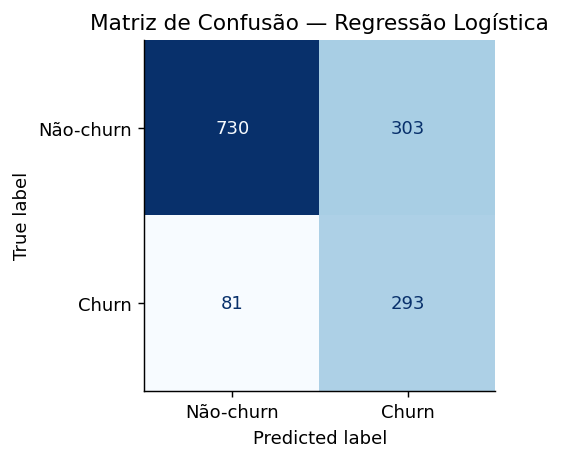

In [73]:
lr_params = dict(C=1.0, class_weight="balanced", solver="lbfgs", max_iter=1000, random_state=SEED)

lr_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf",  LogisticRegression(**lr_params)),
])

with mlflow.start_run(run_name="logistic_regression") as lr_run:
    # — tags
    mlflow.set_tags({**DATASET_TAGS, "model.type": "logistic_regression"})

    # — parâmetros do modelo e do pré-processamento
    mlflow.log_params({
        "model":           "LogisticRegression",
        "C":               lr_params["C"],
        "class_weight":    lr_params["class_weight"],
        "solver":          lr_params["solver"],
        "max_iter":        lr_params["max_iter"],
        "random_state":    SEED,
        "preprocessing":   "StandardScaler+OrdinalEncoder+OHE",
        "drop_features":   "customerID,TotalCharges",
        "cv_folds":        5,
    })

    # Treino no conjunto completo de treino
    lr_pipe.fit(X_train, y_train)
    lr_y_pred = lr_pipe.predict(X_test)
    lr_y_prob = lr_pipe.predict_proba(X_test)[:, 1]

    # Métricas no conjunto de teste
    test_auc = roc_auc_score(y_test, lr_y_prob)
    test_pr  = average_precision_score(y_test, lr_y_prob)
    test_f1  = f1_score(y_test, lr_y_pred)

    mlflow.log_metrics({
        "test.auc_roc": test_auc,
        "test.pr_auc":  test_pr,
        "test.f1":      test_f1,
    })

    # Validação cruzada — 5-fold estratificado
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_scores = cross_validate(
        lr_pipe, X, y, cv=cv,
        scoring={"roc_auc": "roc_auc", "avg_precision": "average_precision", "f1": "f1"},
    )
    mlflow.log_metrics({
        "cv.auc_roc_mean":  cv_scores["test_roc_auc"].mean(),
        "cv.auc_roc_std":   cv_scores["test_roc_auc"].std(),
        "cv.pr_auc_mean":   cv_scores["test_avg_precision"].mean(),
        "cv.pr_auc_std":    cv_scores["test_avg_precision"].std(),
        "cv.f1_mean":       cv_scores["test_f1"].mean(),
        "cv.f1_std":        cv_scores["test_f1"].std(),
    })

    # Artefato: modelo serializado com assinatura automática
    signature = mlflow.models.infer_signature(X_train, lr_pipe.predict_proba(X_train)[:, 1])
    mlflow.sklearn.log_model(lr_pipe, artifact_path="model", signature=signature)

    LR_RUN_ID = lr_run.info.run_id

print(f"\nRun ID: {LR_RUN_ID}")
print(f"test.auc_roc={test_auc:.4f} | test.pr_auc={test_pr:.4f} | test.f1={test_f1:.4f}  ✓ logado")

# Relatório e matriz de confusão
print()
print(classification_report(y_test, lr_y_pred, target_names=["Não-churn", "Churn"]))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, lr_y_pred),
    display_labels=["Não-churn", "Churn"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de Confusão — Regressão Logística")
plt.tight_layout()
plt.show()

### 3.1 Validação cruzada — confirmar que o resultado não é sorte do split

Usamos Stratified K-Fold com 5 folds para estimar a variância do modelo.

In [57]:
print("Validação cruzada — Regressão Logística (5-fold estratificado)\n")
for metric, key in [("AUC-ROC", "test_roc_auc"), ("PR-AUC", "test_avg_precision"), ("F1", "test_f1")]:
    scores = cv_scores[key]
    print(f"  {metric:<10} {scores.mean():.4f} ± {scores.std():.4f}  (folds: {np.round(scores, 4)})")

print(f"\n(métricas cv.* já registradas no run MLflow: {LR_RUN_ID})")

Validação cruzada — Regressão Logística (5-fold estratificado)

  AUC-ROC    0.8428 ± 0.0028  (folds: [0.8457 0.846  0.8423 0.8416 0.8383])
  PR-AUC     0.6522 ± 0.0143  (folds: [0.648  0.6568 0.6331 0.6469 0.6764])
  F1         0.6262 ± 0.0094  (folds: [0.6398 0.6291 0.6271 0.6245 0.6105])

(métricas cv.* já registradas no run MLflow: 7d080bb41c74410d82a78262b98bc968)


## 4. Curvas ROC e Precision-Recall — todos os modelos juntos

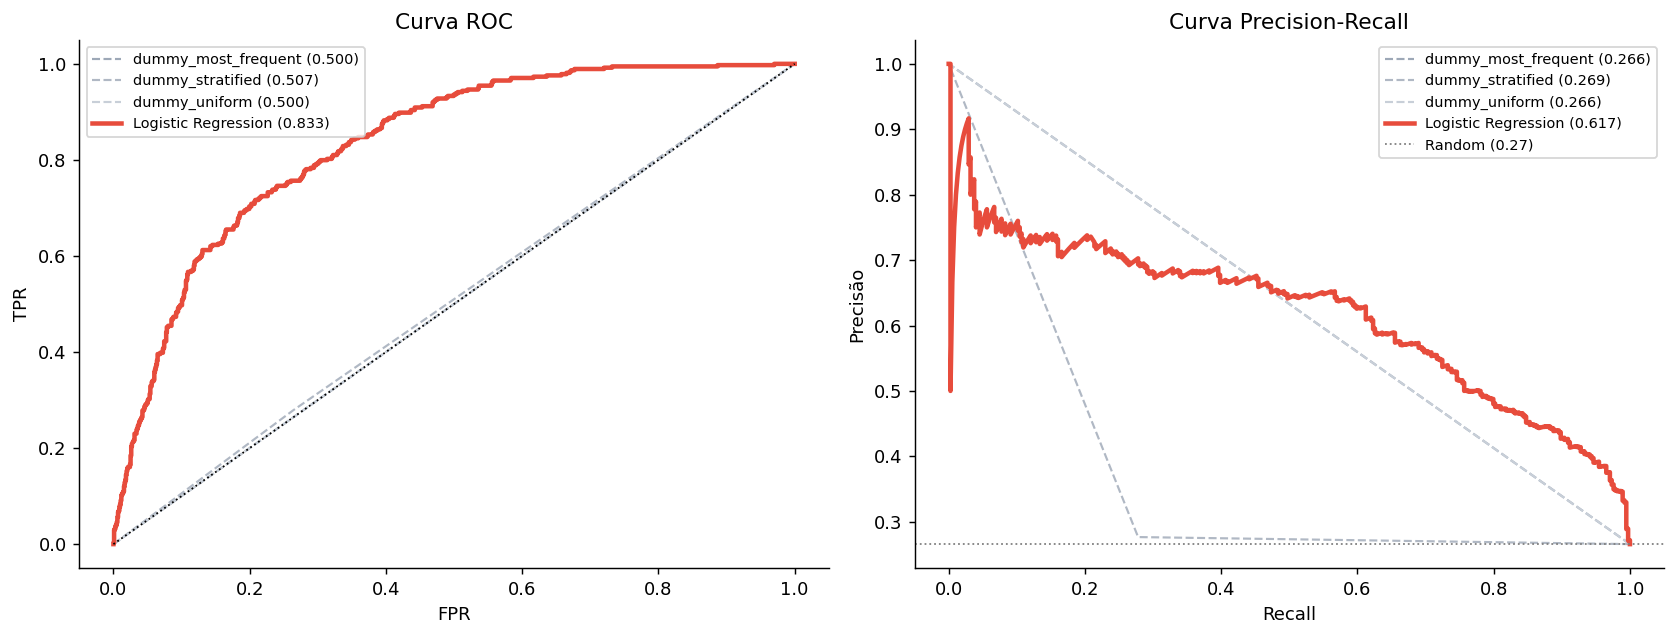

In [58]:
all_models = {
    **{k: v for k, v in dummy_results.items()},
    "Logistic Regression": {
        "y_pred": lr_y_pred,
        "y_prob": lr_y_prob,
        "auc_roc": roc_auc_score(y_test, lr_y_prob),
        "pr_auc":  average_precision_score(y_test, lr_y_prob),
        "f1":      f1_score(y_test, lr_y_pred),
    },
}

colors = ["#9da8b7", "#b0b8c4", "#c8cfd8", "#E74C3C"]
baseline_rate = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for (name, r), color in zip(all_models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    prec, rec, _ = precision_recall_curve(y_test, r["y_prob"])
    lw = 2.5 if "Logistic" in name else 1.2
    ls = "-" if "Logistic" in name else "--"
    axes[0].plot(fpr, tpr, color=color, lw=lw, ls=ls, label=f"{name} ({r['auc_roc']:.3f})")
    axes[1].plot(rec, prec, color=color, lw=lw, ls=ls, label=f"{name} ({r['pr_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], "k:", lw=1)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("Curva ROC"); axes[0].legend(fontsize=8)

axes[1].axhline(baseline_rate, color="gray", ls=":", lw=1, label=f"Random ({baseline_rate:.2f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precisão")
axes[1].set_title("Curva Precision-Recall"); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Análise dos coeficientes — o que a Regressão Logística aprendeu

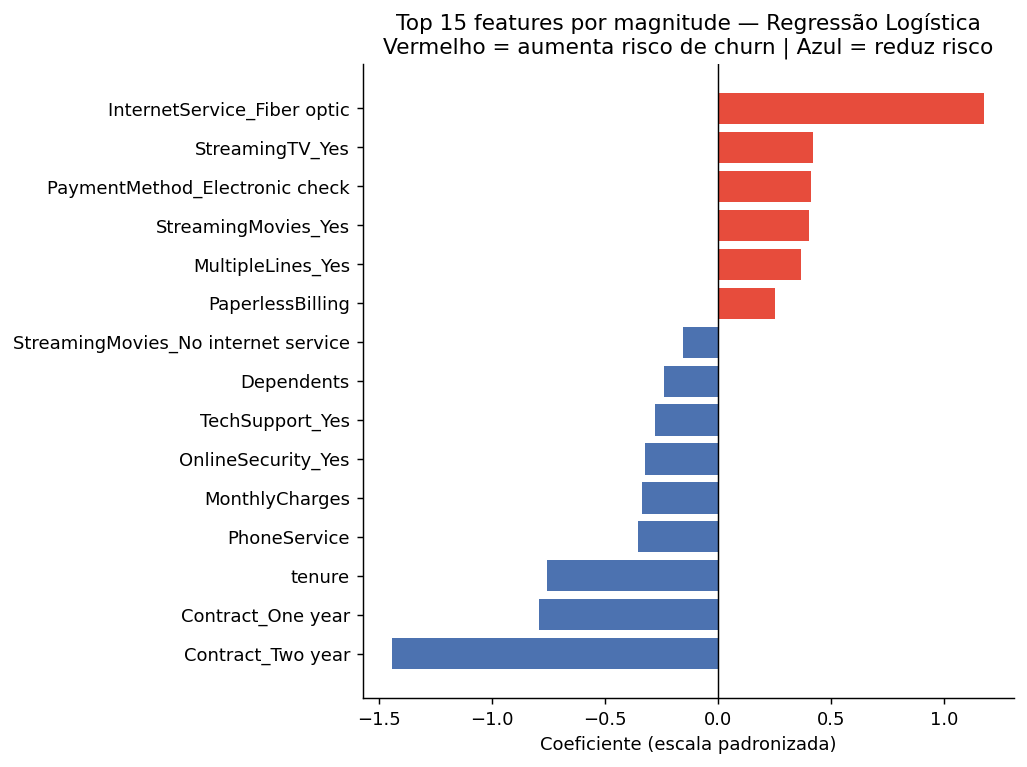

In [59]:
# Recuperar nomes das features após o ColumnTransformer
ohe_feature_names = (
    lr_pipe.named_steps["prep"]
    .named_transformers_["ohe"]
    .get_feature_names_out(ohe_cols)
    .tolist()
)
feature_names = num_cols + binary_cols + ohe_feature_names

coef = lr_pipe.named_steps["clf"].coef_[0]
coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": coef})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .head(15)
    .sort_values("coef")
)

fig, ax = plt.subplots(figsize=(8, 6))
colors_bar = ["#E74C3C" if c > 0 else "#4C72B0" for c in coef_df["coef"]]
ax.barh(coef_df["feature"], coef_df["coef"], color=colors_bar)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coeficiente (escala padronizada)")
ax.set_title("Top 15 features por magnitude — Regressão Logística\nVermelho = aumenta risco de churn | Azul = reduz risco")
plt.tight_layout()
plt.show()

## 6. Scorecard comparativo final

                     AUC-ROC  PR-AUC  F1 (churn)           Tipo
Modelo                                                         
dummy_most_frequent   0.5000  0.2658      0.0000  Baseline real
dummy_stratified      0.5074  0.2688      0.2773  Baseline real
dummy_uniform         0.5000  0.2658      0.3763  Baseline real
Logistic Regression   0.8330  0.6170      0.6041  Baseline real


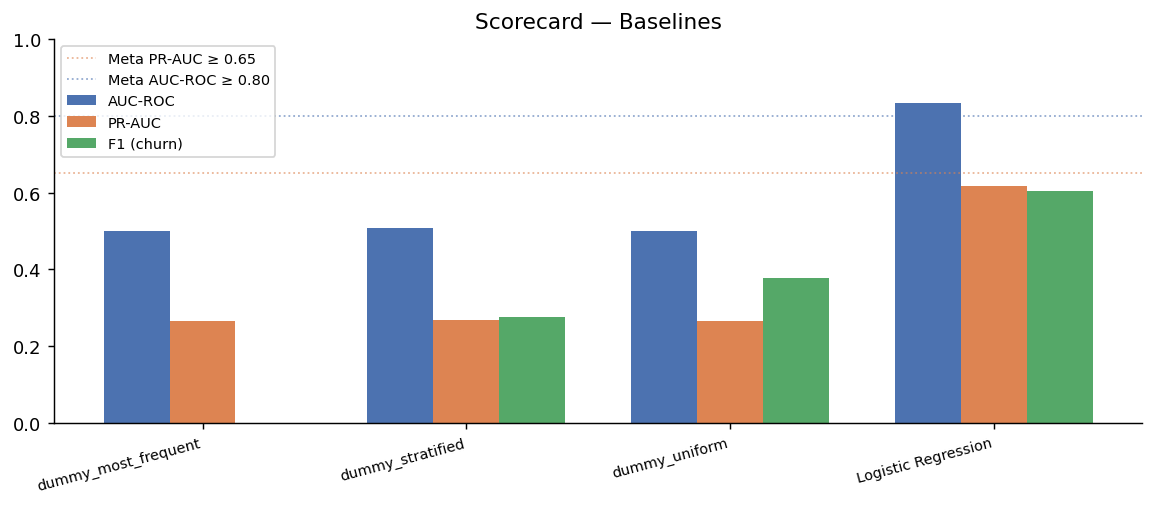

In [60]:
rows = []
for name, r in all_models.items():
    rows.append({
        "Modelo":   name,
        "AUC-ROC":  round(r["auc_roc"], 4),
        "PR-AUC":   round(r["pr_auc"],  4),
        "F1 (churn)": round(r["f1"],    4),
        "Tipo": "Dummy" if "Dummy" in name else "Baseline real",
    })

scorecard = pd.DataFrame(rows).set_index("Modelo")
print(scorecard.to_string())

# Visualização
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(scorecard))
w = 0.25
ax.bar(x - w,   scorecard["AUC-ROC"],    width=w, label="AUC-ROC",    color="#4C72B0")
ax.bar(x,       scorecard["PR-AUC"],     width=w, label="PR-AUC",     color="#DD8452")
ax.bar(x + w,   scorecard["F1 (churn)"], width=w, label="F1 (churn)", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(scorecard.index, rotation=15, ha="right", fontsize=8)
ax.set_ylim(0, 1)
ax.axhline(0.65, color="#DD8452", ls=":", lw=1, alpha=0.6, label="Meta PR-AUC ≥ 0.65")
ax.axhline(0.80, color="#4C72B0", ls=":", lw=1, alpha=0.6, label="Meta AUC-ROC ≥ 0.80")
ax.set_title("Scorecard — Baselines")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Conclusões

### O que estabelecemos

| Modelo | Papel |
|---|---|
| `DummyClassifier most_frequent` | Piso absoluto — AUC-ROC ≈ 0.5, F1 = 0 para churn |
| `DummyClassifier stratified/uniform` | Piso aleatório — PR-AUC ≈ taxa de churn (~0.26) |
| **Regressão Logística** | **Baseline real — referência para modelos futuros** |

### Próximos passos

Os modelos mais avançados (Random Forest, XGBoost, etc.) precisam superar a Regressão Logística em:
1. **PR-AUC** — métrica primária (dados desbalanceados)
2. **AUC-ROC** — benchmark geral
3. **Custo de negócio** — árbitro final (ver notebook `Metricas.ipynb`)

## MLflow — consultar os runs registrados

In [61]:
runs = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=["metrics.test.pr_auc DESC"],
)

display_cols = [
    "tags.mlflow.runName",
    "params.model", "params.strategy", "params.C",
    "metrics.test.auc_roc", "metrics.test.pr_auc", "metrics.test.f1",
    "metrics.cv.pr_auc_mean", "metrics.cv.pr_auc_std",
    "tags.dataset.md5", "tags.dataset.git_commit",
    "start_time",
]
display_cols = [c for c in display_cols if c in runs.columns]
print(runs[display_cols].to_string(index=False))

print(f"\n→ Para abrir a UI do MLflow, execute no terminal:")
print(f"  cd project && mlflow ui --backend-store-uri mlruns --port 5000")

tags.mlflow.runName       params.model params.strategy params.C  metrics.test.auc_roc  metrics.test.pr_auc  metrics.test.f1  metrics.cv.pr_auc_mean  metrics.cv.pr_auc_std                 tags.dataset.md5 tags.dataset.git_commit                       start_time
logistic_regression LogisticRegression            None      1.0              0.833020             0.617035         0.604124                0.652236               0.014265 0f9de68e012bd3aed5fa7cdc9fc421af                 9452077 2026-04-04 18:44:39.474000+00:00
logistic_regression LogisticRegression            None      1.0              0.833020             0.617035         0.604124                0.652236               0.014265 0f9de68e012bd3aed5fa7cdc9fc421af                 9452077 2026-04-04 18:43:07.392000+00:00
logistic_regression LogisticRegression            None      1.0              0.833020             0.617035         0.604124                0.652236               0.014265 0f9de68e012bd3aed5fa7cdc9fc421af              